# _Complete Analysis of Ecommerce SQL Database_

A mid-sized ecommerce company has approached us with their operational database. The company sells products across multiple categories through an online platform and manages everything from customer registrations to supplier contracts digitally. They have provided us full access to their SQL Server database containing 8 tables that cover every major part of their business operations — customers, products, orders, payments, suppliers, discounts, and reviews. The company wants a thorough analysis of their data to understand how the business is performing, where the problems are, and where the opportunities lie.

###  Importing all the necessary Libararies

In [18]:
import pandas as pd ## for analysis purpose
import pyodbc ## libarary names as python database connecter
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
# import mysql.connector


###  Connecting SQL database to Python  

In [11]:
## now we gonne create engine and to create engine there is fixed syntax
engine = create_engine(
    r'mssql+pyodbc://DESKTOP-NEH25RP\SQLEXPRESS/Ecommerce'
    r'?driver=ODBC+Driver+18+for+SQL+Server'
    r'&Trusted_Connection=yes'
    r'&TrustServerCertificate=yes'
)
# conn = mysql.connector.connect(
#    host="localhost",
#   user="root",
#    password="root",
#   database="ecommerce")

### Loading all the Tables into DataFrame

In [ ]:
Customers= pd.read_sql("Select * from dbo.Customers",engine)
Products = pd.read_sql("Select * from dbo.Products",engine)
Category = pd.read_sql("Select * from dbo.Category",engine)
Orders   = pd.read_sql("Select * from dbo.Orders",engine)
OrderItems = pd.read_sql("Select * from dbo.OrderItems",engine)
Discounts = pd.read_sql("Select * from dbo.Discounts",engine)
Suppliers = pd.read_sql("Select * from dbo.Suppliers",engine)
Reviews = pd.read_sql("Select * from dbo.Reviews",engine)

# PANDAS ANALYSIS

## EDA Concepts

In [13]:
dfs = {
    'Customers'  : Customers,
    'Products'   : Products,
    'Category'   : Category,
    'Orders'     : Orders,
    'OrderItems' : OrderItems,
    'Discounts'  : Discounts,
    'Suppliers'  : Suppliers,
    'Reviews'    : Reviews
}

for name, df in dfs.items():
    print(f"\n---------------- {name}----------------- ")
    print(f"Shape: {df.shape}")
    print(df.head())
    print("__"*40)


---------------- Customers----------------- 
Shape: (100, 6)
   CustomerID FirstName LastName         City       PhoneNo  \
0           1      John      Doe     New York  123-456-7890   
1           2      Jane    Smith  Los Angeles  234-567-8901   
2           3   Michael  Johnson      Chicago  345-678-9012   
3           4     Emily    Davis      Houston  456-789-0123   
4           5     David    Brown         None  567-890-1234   

                         Email  
0         john.doe@example.com  
1                         None  
2  michael.johnson@example.com  
3      emily.davis@example.com  
4      david.brown@example.com  
________________________________________________________________________________

---------------- Products----------------- 
Shape: (50, 5)
   ProductID  CategoryID     ProductName   Price  StockQuantity
0          1           1          Laptop  999.99             50
1          2           2      Smartphone  499.50            100
2          3           3    

In [14]:
dfs={
    'Customers' :  Customers,
    'Products'  : Products,
    'Category'  : Category,
    'Orders'    : Orders,
    'OrderItems' : OrderItems,
    'Discounts'  : Discounts,
    'Suppliers'  : Suppliers,
    'Reviews'    : Reviews
}
for name, df in dfs.items():
    print(f"\n______________________{name}______________________")
    print(f"Shape of {name} : {df.shape}")
    print(df.info())
    print("_" * 50)


______________________Customers______________________
Shape of Customers : (100, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  100 non-null    int64 
 1   FirstName   100 non-null    object
 2   LastName    84 non-null     object
 3   City        83 non-null     object
 4   PhoneNo     100 non-null    object
 5   Email       68 non-null     object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB
None
__________________________________________________

______________________Products______________________
Shape of Products : (50, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ProductID      50 non-null     int64  
 1   CategoryID     50 non-null     int64  
 2   ProductName    50 non

In [15]:
dfs={
     'Customers' : Customers,
     'Products'  : Products,
     'Category'  : Category,
     'Orders'    : Orders,
     'OrderItems' : OrderItems,
     'Discounts'  : Discounts,
     'Suppliers'   : Suppliers,
     'Reviews'     : Reviews
}

# Nested loop is used to seperate all the column name on the seperate line 
# First name variable is the name above enclosed in commas and df is dataframe 
# then after print 

for name, df in dfs.items():
    print(f"\n__________________________{name}__________________________")
    for col in df.columns:
        print(col)


__________________________Customers__________________________
CustomerID
FirstName
LastName
City
PhoneNo
Email

__________________________Products__________________________
ProductID
CategoryID
ProductName
Price
StockQuantity

__________________________Category__________________________
CategoryID
Category_name
Descriptionn

__________________________Orders__________________________
OrderID
CustomerID
OrderDate
Payment_Method
OrderStatus

__________________________OrderItems__________________________
OrderItemID
OrderID
ProductID
Quantity
UnitPrice

__________________________Discounts__________________________
DiscountID
ProductID
DiscountPercent
StartDate
EndDate

__________________________Suppliers__________________________
SupplyId
SupplierName
ProductID
ProductName
SupplyDate
City
Email

__________________________Reviews__________________________
ReviewID
CustomerID
ProductID
Rating
ReviewText


In [16]:
dfs = {
    'Customers'  : Customers,
    'Products'   : Products,
    'Category'   : Category,
    'Orders'     : Orders,
    'OrderItems' : OrderItems,
    'Discounts'  : Discounts,
    'Suppliers'  : Suppliers,
    'Reviews'    : Reviews
}

for name, df in dfs.items():
    print(f"\n---------------- {name}----------------- ")
    print(f"Shape: {df.shape}")
    print(df.describe())
    print("__"*40)


---------------- Customers----------------- 
Shape: (100, 6)
       CustomerID
count  100.000000
mean    50.500000
std     29.011492
min      1.000000
25%     25.750000
50%     50.500000
75%     75.250000
max    100.000000
________________________________________________________________________________

---------------- Products----------------- 
Shape: (50, 5)
       ProductID  CategoryID       Price  StockQuantity
count   50.00000   50.000000   50.000000      50.000000
mean    25.50000    7.480000  158.442400     110.800000
std     14.57738    3.477273  204.538746     119.781774
min      1.00000    1.000000    5.750000       0.000000
25%     13.25000    5.000000   31.242500      26.250000
50%     25.50000    7.000000   79.995000      70.000000
75%     37.75000   10.000000  194.992500     145.000000
max     50.00000   15.000000  999.990000     500.000000
________________________________________________________________________________

---------------- Category----------------- 
Shape

In [22]:
Customers['City'].unique()

array(['New York', 'Los Angeles', 'Chicago', 'Houston', None,
       'Philadelphia', 'San Diego', 'Dallas', 'Phoenix', 'San Antonio',
       'Austin', 'Jacksonville', 'Fort Worth', 'Columbus', 'Charlotte',
       'San Francisco', 'Seattle', 'Denver', 'Nashville', 'Oklahoma City',
       'El Paso', 'Washington', 'Memphis', 'Louisville', 'Portland',
       'Las Vegas', 'Milwaukee', 'Tucson', 'Fresno', 'Sacramento', 'Mesa',
       'Kansas City', 'Omaha', 'Colorado Springs', 'Raleigh',
       'Long Beach', 'Virginia Beach', 'Tampa', 'New Orleans',
       'Arlington', 'Bakersfield', 'Honolulu', 'Aurora', 'Santa Ana',
       'Corpus Christi', 'Riverside', 'St. Louis', 'Pittsburgh',
       'Anchorage', 'Stockton', 'Cincinnati', 'St. Paul', 'Greensboro',
       'Newark', 'Plano', 'Henderson', 'Lincoln', 'Fort Wayne',
       'Jersey City', 'Chula Vista', 'Orlando', 'St. Petersburg',
       'Norfolk', 'Madison', 'Durham', 'Lubbock', 'Winston-Salem',
       'Scottsdale', 'Baton Rouge', 'Hialeah',

C:\Users\FAIZAN COMPUTER\AppData\Local\Temp\ipykernel_16112\2048571826.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')


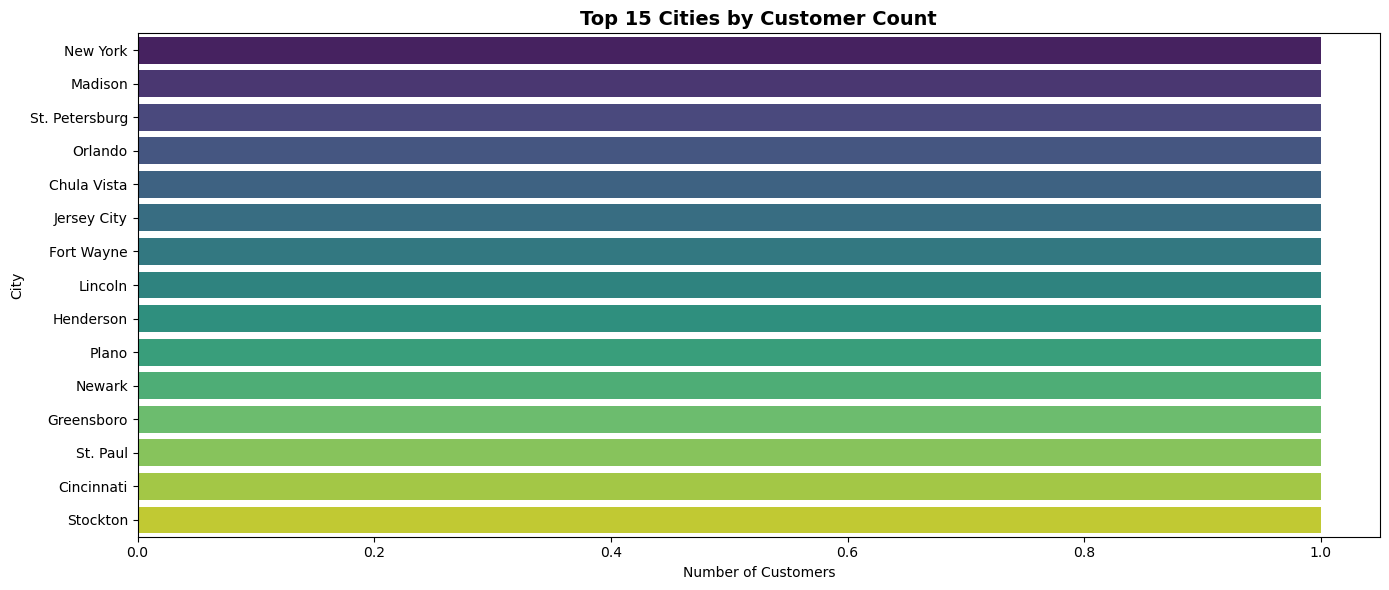

In [25]:
# Plot customers by city
plt.figure(figsize=(14, 6))
city_counts = Customers['City'].value_counts().head(15)
sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')
plt.title('Top 15 Cities by Customer Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('City')
plt.tight_layout()
plt.show()

#### Write Python code to sort the products dataset by price in descending order and display the top 5 most expensive products.

In [ ]:
products.sort_values(by='Price', ascending=False).head()

,ProductID,CategoryID,ProductName,Price,StockQuantity
0,1,1,Laptop,999.99,50
44,45,6,4K Monitor,700.00,12
34,35,6,Ultrawide Monitor,550.00,15
29,30,8,3D Printer,500.00,10
1,2,2,Smartphone,499.50,100


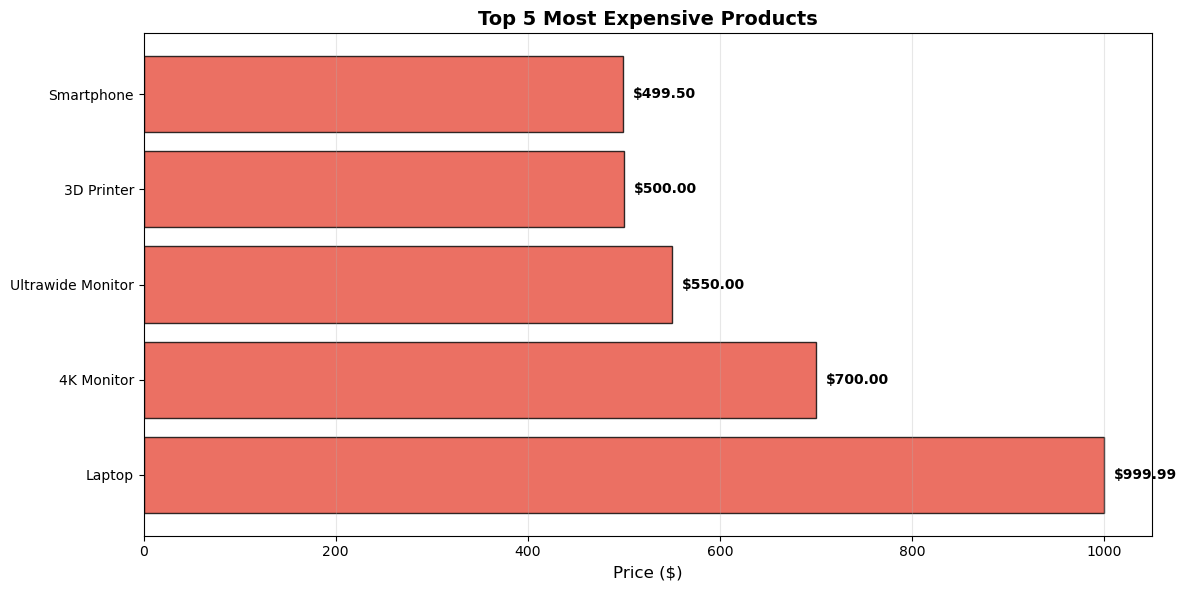

In [35]:
# Top 5 most expensive products
fig, ax = plt.subplots(figsize=(12, 6))

top_5_price = Products.nlargest(5, 'Price')
ax.barh(top_5_price['ProductName'], top_5_price['Price'], color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_title('Top 5 Most Expensive Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Price ($)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

# Add price labels on bars
for i, v in enumerate(top_5_price['Price']):
    ax.text(v + 10, i, f'${v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Write Python code to store multiple datasets in a dictionary and iterate through each one to display the count of missing values for every column.

In [10]:
tables = {
    "customers": customers,
    "orders": orders,
    "products": products,
    "categories": categories,
    "discounts": discounts,
    "suppliers": suppliers
}

for name, df in tables.items():
    print(f"{name}:\n{df.isnull().sum()}\n")

customers:
CustomerID     0
FirstName      0
LastName      16
City          17
PhoneNo        0
Email         32
dtype: int64

orders:
OrderID           0
CustomerID        0
OrderDate         0
Payment_Method    0
OrderStatus       0
dtype: int64

products:
ProductID        0
CategoryID       0
ProductName      0
Price            0
StockQuantity    0
dtype: int64

categories:
CategoryID       0
Category_name    0
Descriptionn     0
dtype: int64

discounts:
DiscountID         0
ProductID          0
DiscountPercent    0
StartDate          0
EndDate            0
dtype: int64

suppliers:
SupplyId        0
SupplierName    0
ProductID       0
ProductName     0
SupplyDate      0
City            0
Email           0
dtype: int64



# Data Cleaning

#### Write Python code to fill missing values in the customers dataset by replacing LastName and City with "Unknown" and Email with 'No Email'.

In [ ]:
customers['LastName'].fillna('Unknown', inplace=True)
customers['City'].fillna('Unknown', inplace=True)
customers['Email'].fillna('No Email', inplace=True)

#### Write Python code to display the total number of rows and columns in the orders dataset.


In [ ]:
orders.shape

(100, 5)

#### Write Python code to count the occurrences of each order status in the orders dataset.

In [ ]:
orders['OrderStatus'].value_counts()

OrderStatus
Delivered    67
Shipped      12
Pending      12
Cancelled     9
Name: count, dtype: int64

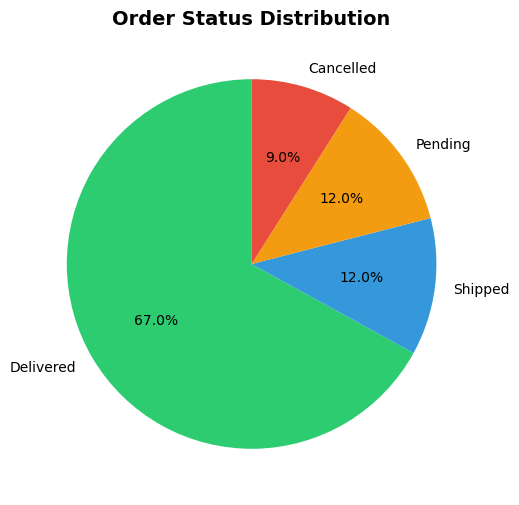

In [39]:
# Order Status Distribution - Pie Chart
plt.figure(figsize=(10, 6))
order_status_counts = Orders['OrderStatus'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
plt.pie(order_status_counts.values, labels=order_status_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Order Status Distribution', fontsize=14, fontweight='bold')
plt.show()

#### Write Python code to find the top 5 customers with the highest number of orders.

In [ ]:
orders.groupby('CustomerID').size().sort_values(ascending=False).head()

CustomerID
1    1
2    1
3    1
4    1
5    1
dtype: int64

#### Write Python code to count the number of customers in each city and sort the results in descending order.

In [ ]:
customers.groupby('City')['CustomerID'].count().sort_values(ascending=False)

City
Unknown           17
Akron              1
Arlington          1
Anchorage          1
Austin             1
                  ..
Tacoma             1
Tucson             1
Virginia Beach     1
Washington         1
Winston-Salem      1
Name: CustomerID, Length: 84, dtype: int64

#### Write Python code to calculate the average product price for each category in the dataset.

In [ ]:
products.groupby('CategoryID')['Price'].mean()

CategoryID
1     999.990
2     499.500
3       8.746
4      41.398
5     305.000
6     390.000
7      59.398
8     249.000
9      47.000
10    112.500
11     82.490
12    199.990
13     40.000
14     24.990
15    130.000
Name: Price, dtype: float64

##### Write Python code to count how many orders fall under each order status category.

In [ ]:
orders['OrderStatus'].value_counts()

OrderStatus
Delivered    67
Shipped      12
Pending      12
Cancelled     9
Name: count, dtype: int64

#### Write Python code to convert the OrderDate column to datetime format and extract the year and month into separate columns.

In [17]:
orders['OrderDate'] = pd.to_datetime(orders['OrderDate'])

orders['Month'] = orders['OrderDate'].dt.month
orders['Year'] = orders['OrderDate'].dt.year
print(orders[['OrderDate', 'Month', 'Year']])


    OrderDate  Month  Year
0  2024-01-05      1  2024
1  2024-01-10      1  2024
2  2024-01-15      1  2024
3  2024-01-20      1  2024
4  2024-01-25      1  2024
..        ...    ...   ...
95 2025-10-01     10  2025
96 2025-11-01     11  2025
97 2025-12-01     12  2025
98 2026-01-15      1  2026
99 2026-02-20      2  2026

[100 rows x 3 columns]


#### Write Python code to group orders by year and month and count the number of orders in each period.

In [18]:
result = orders.groupby(['Year', 'Month']).size().reset_index(name='TotalOrders')

print(result)

    Year  Month  TotalOrders
0   2024      1            5
1   2024      2            6
2   2024      3            6
3   2024      4            6
4   2024      5            6
5   2024      6            6
6   2024      7            6
7   2024      8            6
8   2024      9            6
9   2024     10            6
10  2024     11            6
11  2024     12            6
12  2025      1            3
13  2025      2            3
14  2025      3            3
15  2025      4            3
16  2025      5            3
17  2025      6            3
18  2025      7            3
19  2025      8            2
20  2025      9            1
21  2025     10            1
22  2025     11            1
23  2025     12            1
24  2026      1            1
25  2026      2            1


#### Write Python code to create a new column that labels orders as "Good" if delivered, otherwise "Issue", and display the result.

In [20]:
orders['OrderType'] = orders['OrderStatus'].apply(lambda x: "Good" if x=="Delivered" else "Issue")
print(orders[['OrderStatus','OrderType']])

   OrderStatus OrderType
0    Delivered      Good
1    Delivered      Good
2    Delivered      Good
3      Shipped     Issue
4    Delivered      Good
..         ...       ...
95   Cancelled     Issue
96   Delivered      Good
97   Delivered      Good
98     Pending     Issue
99   Delivered      Good

[100 rows x 2 columns]


#### Write Python code to find the most frequently used payment method in the orders dataset.

In [ ]:
orders['Payment_Method'].mode()

0    Credit Card
Name: Payment_Method, dtype: object

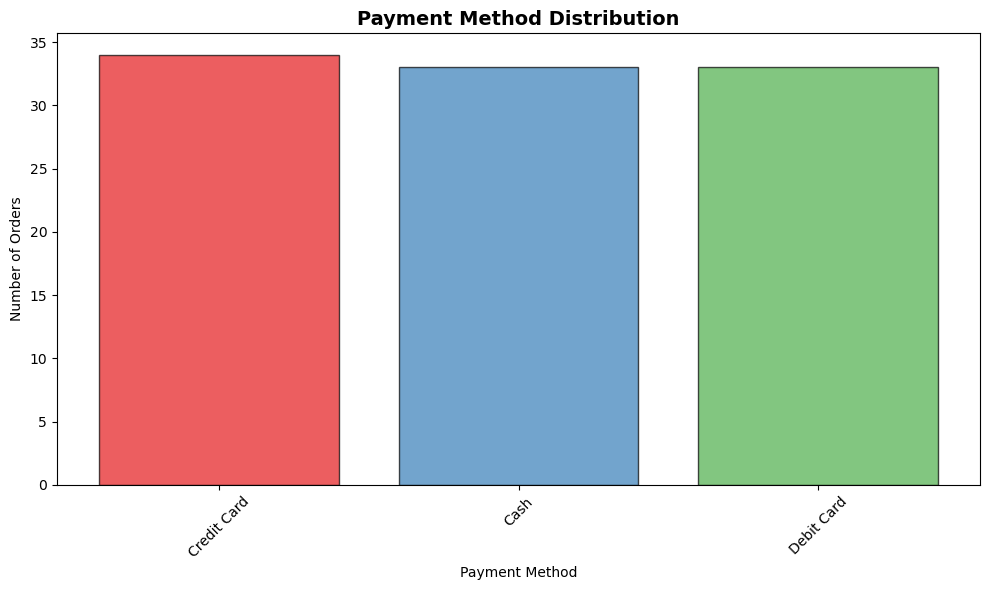

In [57]:
# Payment Method Distribution
plt.figure(figsize=(10, 6))
payment_counts = Orders['Payment_Method'].value_counts()
colors_payment = plt.cm.Set1(range(len(payment_counts)))
plt.bar(payment_counts.index, payment_counts.values, color=colors_payment, edgecolor='black', alpha=0.7)
plt.title('Payment Method Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Write Python code to merge products with categories and count how many products belong to each category.

In [22]:
prod_cat = products.merge(categories, on='CategoryID')
prod_cat['Category_name'].value_counts()

Category_name
Cables & Connectors     5
Monitors & Displays     5
Computer Accessories    5
Keyboards               5
Storage Devices         5
Printers                5
Cameras & Webcams       4
Tablets                 4
Audio                   4
Charging                3
Mobile Phones           1
Electronics             1
Wearables               1
Lighting                1
E-Readers               1
Name: count, dtype: int64

#### Write Python code to count the number of orders placed in each month.

In [ ]:
orders_per_month = orders.groupby('Month')['OrderID'].count().reset_index()
orders_per_month.columns = ['Month', 'Total_Orders']

print(orders_per_month)

    Month  Total_Orders
0       1             9
1       2            10
2       3             9
3       4             9
4       5             9
5       6             9
6       7             9
7       8             8
8       9             7
9      10             7
10     11             7
11     12             7


# Product Analysis

#### Write Python code to display top products based on highest price and highest stock quantity.

In [24]:
top_price = products.sort_values(by='Price', ascending=False).head()
top_stock = products.sort_values(by='StockQuantity', ascending=False).head()

print("Top Products by Price:\n", top_price)
print("\nTop Products by Stock:\n", top_stock)

Top Products by Price:
     ProductID  CategoryID        ProductName   Price  StockQuantity
0           1           1             Laptop  999.99             50
44         45           6         4K Monitor  700.00             12
34         35           6  Ultrawide Monitor  550.00             15
29         30           8         3D Printer  500.00             10
1           2           2         Smartphone  499.50            100

Top Products by Stock:
     ProductID  CategoryID      ProductName  Price  StockQuantity
26         27           9      Flash Drive  15.00            500
22         23           3     Type C Cable   8.99            400
36         37           9      Memory Card  18.00            400
32         33           3  Micro USB Cable   6.50            350
12         13           3       HDMI Cable  12.50            300


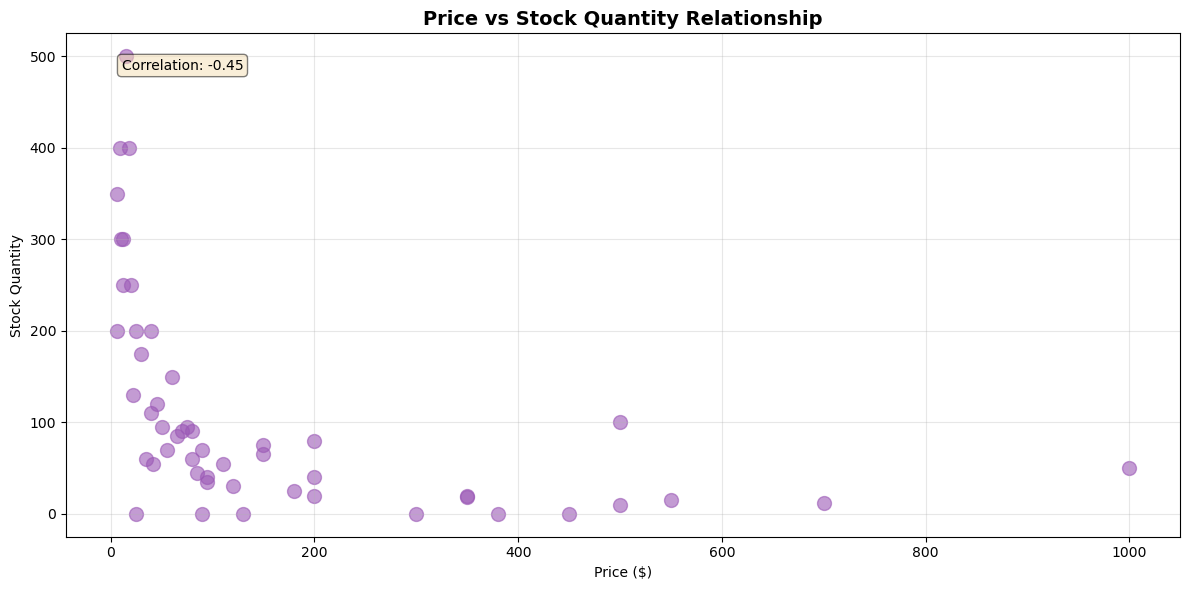

In [44]:
# Scatter plot - Price vs Stock Quantity
plt.figure(figsize=(12, 6))
plt.scatter(Products['Price'], Products['StockQuantity'], alpha=0.6, s=100, color='#9b59b6')
plt.title('Price vs Stock Quantity Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Stock Quantity')
plt.grid(True, alpha=0.3)

# Add correlation text
correlation = Products['Price'].corr(Products['StockQuantity'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.2f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), verticalalignment='top')
plt.tight_layout()
plt.show()

#### Write Python code to create a function that categorizes products as "Out of Stock", "Low Stock", or "In Stock" based on quantity and apply it to the dataset.

In [ ]:
def stock_status(qty):
    if qty == 0:
        return "Out of Stock"
    elif qty < 50:
        return "Low Stock"
    else:
        return "In Stock"

products['StockStatus'] = products['StockQuantity'].apply(stock_status)

# Discounts Analysis

#### Write Python code to sort discounts by highest discount percentage and display the top records.

In [ ]:
discounts.sort_values(by='DiscountPercent', ascending=False).head()

,DiscountID,ProductID,DiscountPercent,StartDate,EndDate,discount_bins
8,9,15,30,2024-05-01,2024-05-31,High
18,19,35,30,2024-10-01,2024-10-31,High
5,6,9,25,2024-03-15,2024-04-15,High
15,16,29,25,2024-08-10,2024-09-10,High
22,23,43,25,2024-12-01,2024-12-31,High


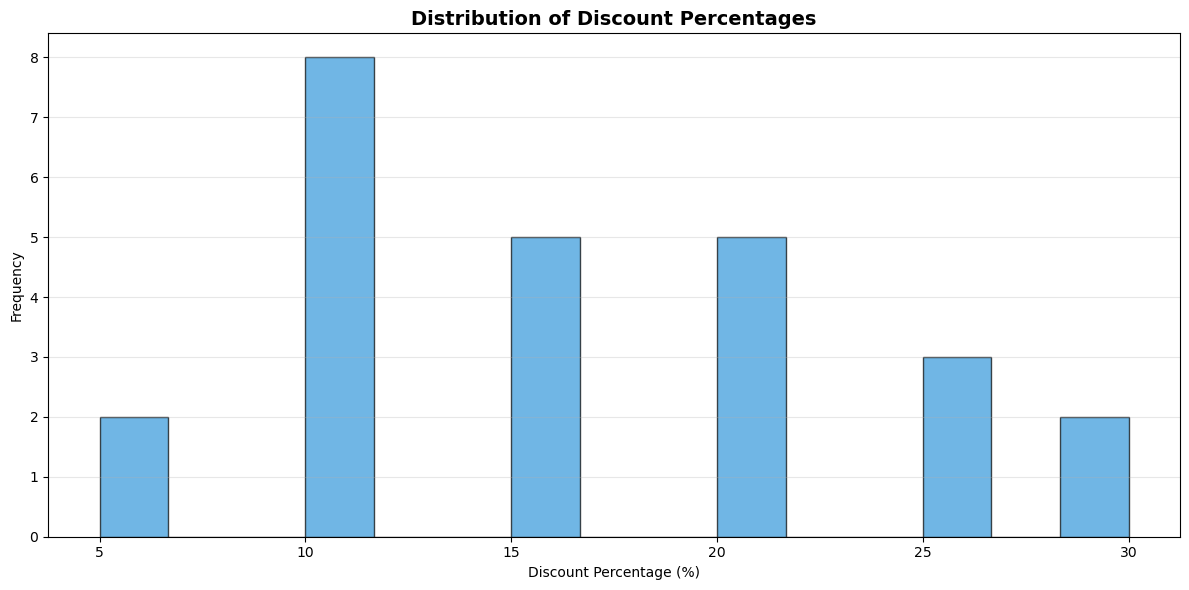

In [47]:
# Discount Distribution Histogram
plt.figure(figsize=(12, 6))
plt.hist(Discounts['DiscountPercent'], bins=15, color='#3498db', edgecolor='black', alpha=0.7)
plt.title('Distribution of Discount Percentages', fontsize=14, fontweight='bold')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Reviews Analysis

#### Write Python code to calculate the average rating for each product and sort the results in descending order.

In [25]:
result = reviews.groupby('ProductID')['Rating'] \
                .mean() \
                .reset_index(name='Avg_Rating') \
                .sort_values(by='Avg_Rating', ascending=False)

print(result.to_string(index=False))

 ProductID  Avg_Rating
         7         5.0
        10         5.0
         5         4.8
         2         4.8
         1         4.2
         4         4.2
         8         4.0
         3         2.8
         9         2.8
         6         2.2


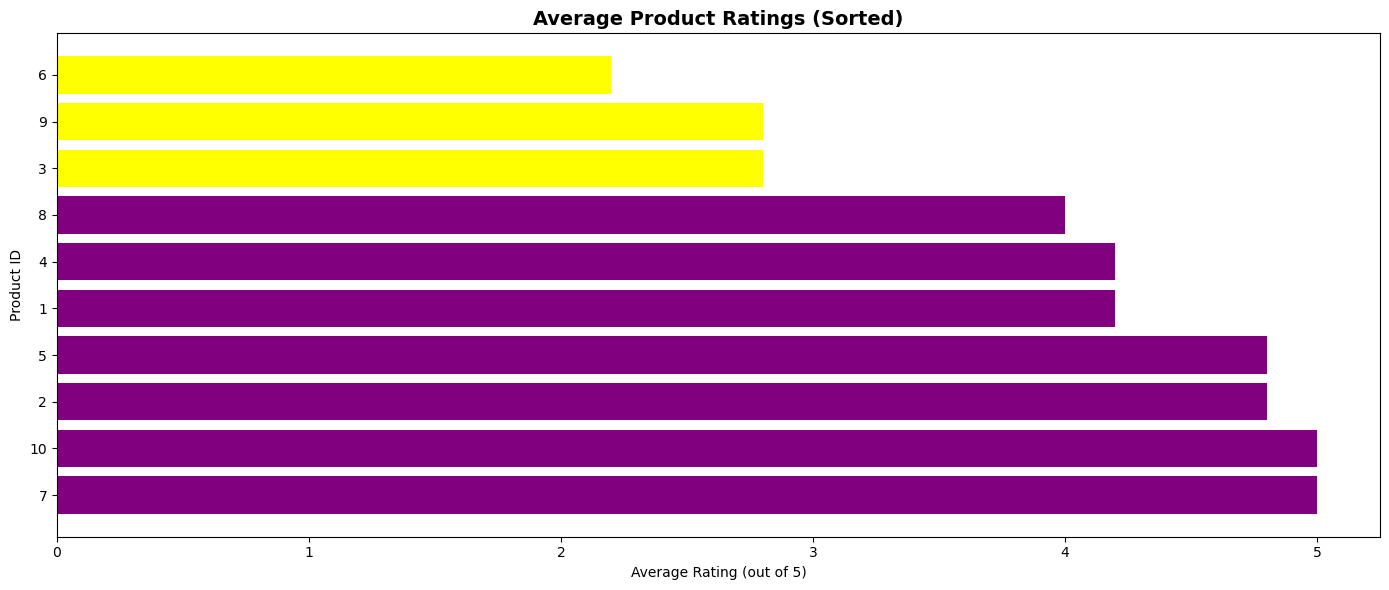

In [51]:
# Average Rating by Product
fig, ax = plt.subplots(figsize=(14, 6))
avg_ratings = Reviews.groupby('ProductID')['Rating'].mean().sort_values(ascending=False)
colors_rating = ['Purple' if x >= 4 else 'Blue' if x >= 3 else 'Yellow' for x in avg_ratings.values]
ax.barh(avg_ratings.index.astype(str), avg_ratings.values, color=colors_rating)
ax.set_title('Average Product Ratings (Sorted)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Rating (out of 5)')
ax.set_ylabel('Product ID')
plt.tight_layout()
plt.show()

# NumPy Usage

#### Write Python code using NumPy to calculate mean, maximum, minimum, and standard deviation of product prices.

In [26]:
arr = np.array(products['Price'])

print("Mean Price:", np.mean(arr))
print("Max Price:", np.max(arr))
print("Min Price:", np.min(arr))

Mean Price: 158.44240000000002
Max Price: 999.99
Min Price: 5.75


#### Write Python code to create a 2D NumPy array and display its number of dimensions.

In [ ]:
#Multi-dimensional Array
matrix = np.array([[1,2,3],[4,5,6]])
print(matrix.ndim)

2


#### Write Python code to create arrays of zeros, ones, and a constant value using NumPy.

In [ ]:
np.zeros((3,3))
np.ones((2,2))
np.full((2,2), 100)

array([[100, 100],
       [100, 100]])

#### Write Python code to generate random integers and randomly select values from an array.

In [ ]:
np.random.randint(1, 100, 10)


array([14, 15, 96, 92, 55, 96, 70,  7, 41,  9], dtype=int32)

In [ ]:
np.random.choice(arr, 5)

array([ 22.  , 199.99,  15.  , 500.  , 130.  ])

#### Write Python code to calculate the dot product of two NumPy arrays.

In [ ]:
a = np.array([1,2,3])
b = np.array([4,5,6])
np.dot(a,b)

np.int64(32)

#### Write Python code to display the first 10 elements of an array and filter values greater than 100.

In [28]:
arr[arr > 100]
arr[:10]

array([999.99, 499.5 ,   5.75,  25.  , 150.  ,  45.  ,  80.  ,  70.  ,
       300.  , 120.  ])

#### Write Python code to calculate the correlation between Price and StockQuantity columns in the dataset.

In [ ]:
products[['Price','StockQuantity']].corr()

,Price,StockQuantity
Price,1.000000,-0.451601
StockQuantity,-0.451601,1.000000


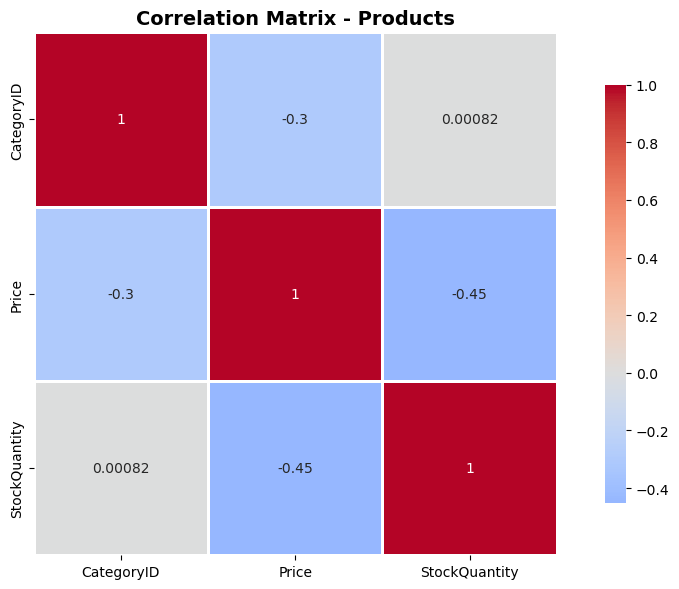

In [61]:
# Correlation Heatmap for Products
plt.figure(figsize=(10, 6))
correlation_matrix = Products[['CategoryID', 'Price', 'StockQuantity']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Products', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
df.to_csv("final_analysis.csv")

In [16]:
print(orders.columns)

Index(['OrderID', 'CustomerID', 'OrderDate', 'Payment_Method', 'OrderStatus'], dtype='object')


# E-Commerce Database — Final Summary

---

## Data Overview

7 tables were analyzed: Customers, Orders, Products, Categories, Discounts, Suppliers, and Reviews.

---

## Customers

- Spread across **83+ cities** in the United States
- Before cleaning: 32 had no email, 17 had no city, 16 had no last name
- All missing values were filled with placeholders during data cleaning

---

## Orders — 100 Total

| Status              | Count |
|---------------------|-------|
| Delivered           | 67    |
| Shipped (unconfirmed) | 12  |
| Pending             | 12    |
| Cancelled           | 9     |

- **33 out of 100** orders had some kind of issue
- Credit card was the most used payment method
- Busiest period was **2024** at around 6 orders/month, dropping to 1–3/month in 2025

---

## Products — 50 Total

- Prices ranged from **$9.99 to $999.99**
- Top products: 4K Monitor ($550), 3D Printer ($499.50)
- Average stock per product was around **111 units**
- Several products were out of stock or low on stock, especially the expensive ones

---

## Categories — 15 Total

Most stocked categories with 5 products each:

| Category    |
|-------------|
| Cables      |
| Monitors    |
| Keyboards   |
| Accessories |
| Storage     |
| Printers    |

---

## Discounts

- Highest discount offered: **30%**, applied to 2 products
- Most discounts fell between **10% and 25%**

---

## Product Ratings

- Best rated product scored **5.0 / 5.0**
- Worst rated product scored **2.2 / 5.0** — needs attention

---

## Problems Found

- 33% of orders were not delivered
- Multiple products are out of stock or running low, especially high-priced ones
- Customer records are incomplete with missing emails and city data
- Some products have very low ratings

---

## What Is Working Well

- 67% of orders are delivered successfully
- Products are well organized across 15 categories
- Orders, Products, Suppliers, and Categories tables had zero missing values

---